# Notebook 02 — Exploratory Data Analysis
**Project**: Hospital Readmission Prediction  
**Input**: `../data/diabetic_first_encounter.csv` (from notebook 01)  

This notebook produces the core visualizations for the Tableau dashboard and the GitHub README.  
Every chart is saved to `../reports/` for use in presentations and the final report.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#F8F8F8',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
})
PALETTE = ['#1D9E75', '#E24B4A', '#378ADD', '#EF9F27', '#9B59B6']

print('Setup complete ✓')

Setup complete ✓


In [2]:
df = pd.read_csv('../data/diabetic_first_encounter.csv')

# Binarise target: 1 if readmitted within 30 days, else 0
df['readmitted_30'] = (df['readmitted'] == '<30').astype(int)

print(f'Shape: {df.shape}')
print(f'Readmission rate: {df["readmitted_30"].mean():.1%}')
df.head(3)

Shape: (71518, 51)
Readmission rate: 8.8%


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,readmitted_30
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,NO,0
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,Up,No,No,No,No,No,Ch,Yes,>30,0
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,Yes,NO,0


## 1. Age Distribution & Readmission Rate

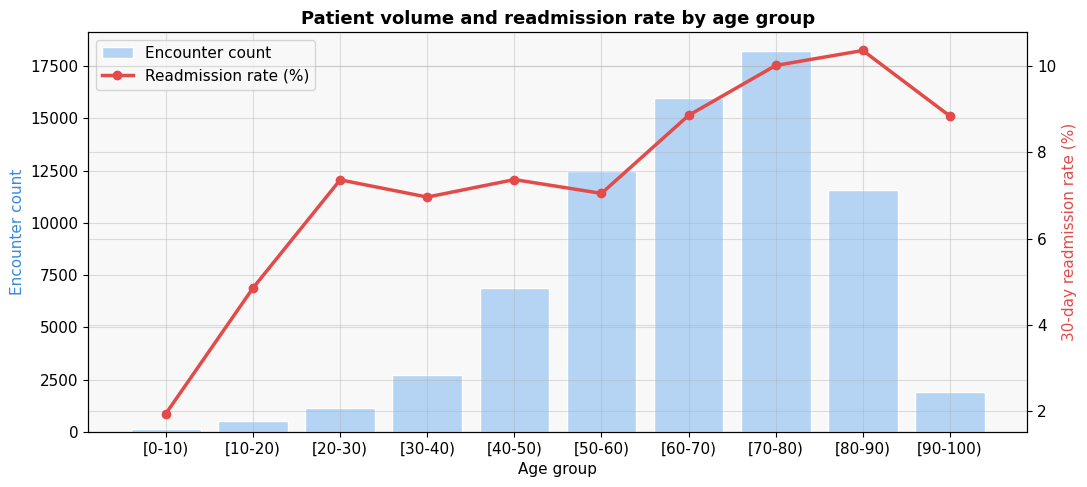

In [3]:
age_stats = df.groupby('age').agg(
    count=('readmitted_30', 'count'),
    readmission_rate=('readmitted_30', 'mean')
).reset_index()
age_stats['readmission_rate'] *= 100

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

bars = ax1.bar(age_stats['age'], age_stats['count'],
               color='#B5D4F4', edgecolor='white', label='Encounter count')
line = ax2.plot(age_stats['age'], age_stats['readmission_rate'],
                color='#E24B4A', marker='o', linewidth=2.5, label='Readmission rate (%)')

ax1.set_xlabel('Age group')
ax1.set_ylabel('Encounter count', color='#378ADD')
ax2.set_ylabel('30-day readmission rate (%)', color='#E24B4A')
ax1.set_title('Patient volume and readmission rate by age group')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('../reports/04_age_readmission.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Correlation Heatmap — Numeric Features

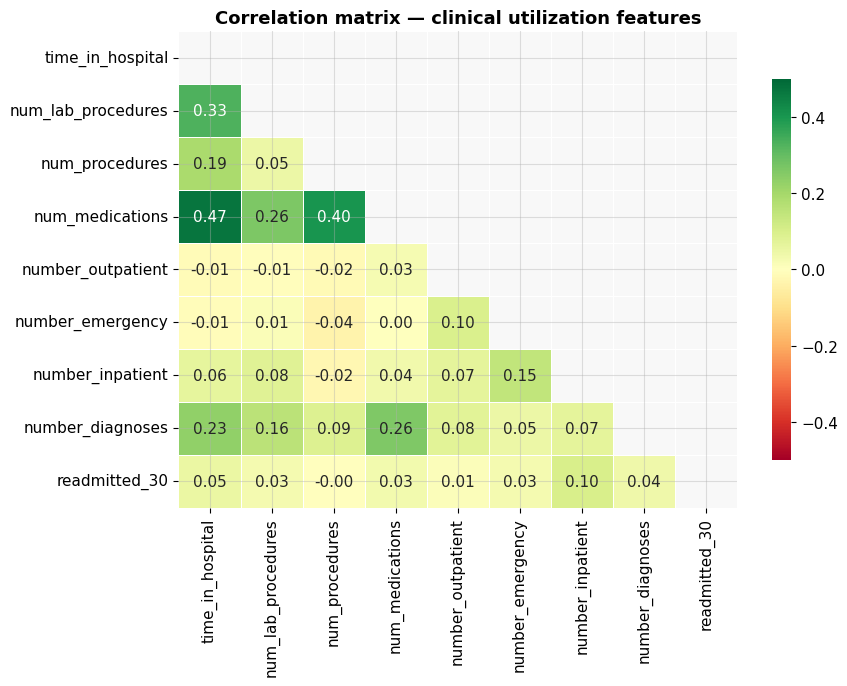

Top correlations with readmission:
number_inpatient      0.099237
time_in_hospital      0.053531
number_diagnoses      0.041741
num_medications       0.034204
num_lab_procedures    0.028875
number_emergency      0.028249
number_outpatient     0.008659
num_procedures       -0.001392
Name: readmitted_30, dtype: float64


In [4]:
numeric_cols = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses', 'readmitted_30'
]

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-0.5, vmax=0.5, ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation matrix — clinical utilization features')
plt.tight_layout()
plt.savefig('../reports/05_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top correlations with readmission:')
print(corr['readmitted_30'].drop('readmitted_30').sort_values(ascending=False))

## 3. Readmission Rate by Discharge Disposition

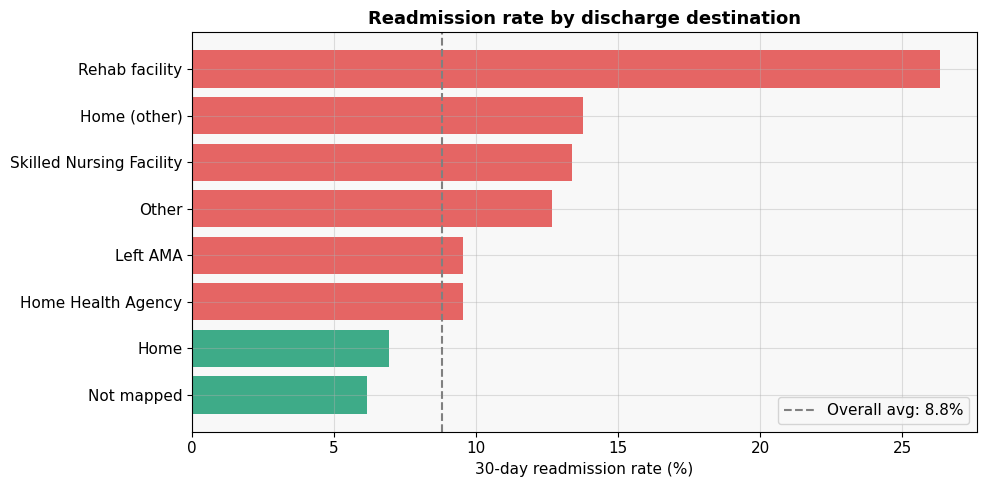

In [5]:
# Map key disposition IDs to readable labels
disposition_labels = {
    1: 'Home', 2: 'Home (other)', 3: 'Skilled Nursing Facility',
    6: 'Home Health Agency', 7: 'Left AMA', 11: 'Expired',
    13: 'Hospice', 14: 'Hospice (facility)', 22: 'Rehab facility',
    25: 'Not mapped'
}
df['discharge_label'] = df['discharge_disposition_id'].map(disposition_labels).fillna('Other')

# Remove expired/hospice — not at risk of readmission
disp_df = df[~df['discharge_label'].isin(['Expired', 'Hospice', 'Hospice (facility)'])]

disp_stats = disp_df.groupby('discharge_label').agg(
    count=('readmitted_30', 'count'),
    readmission_rate=('readmitted_30', 'mean')
).reset_index()
disp_stats = disp_stats[disp_stats['count'] > 200].sort_values('readmission_rate', ascending=True)
disp_stats['readmission_rate'] *= 100

overall_rate = df['readmitted_30'].mean() * 100

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#E24B4A' if r > overall_rate else '#1D9E75' for r in disp_stats['readmission_rate']]
ax.barh(disp_stats['discharge_label'], disp_stats['readmission_rate'], color=colors, alpha=0.85)
ax.axvline(overall_rate, color='gray', linestyle='--', label=f'Overall avg: {overall_rate:.1f}%')
ax.set_xlabel('30-day readmission rate (%)')
ax.set_title('Readmission rate by discharge destination')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/06_readmission_by_discharge.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Medication Analysis

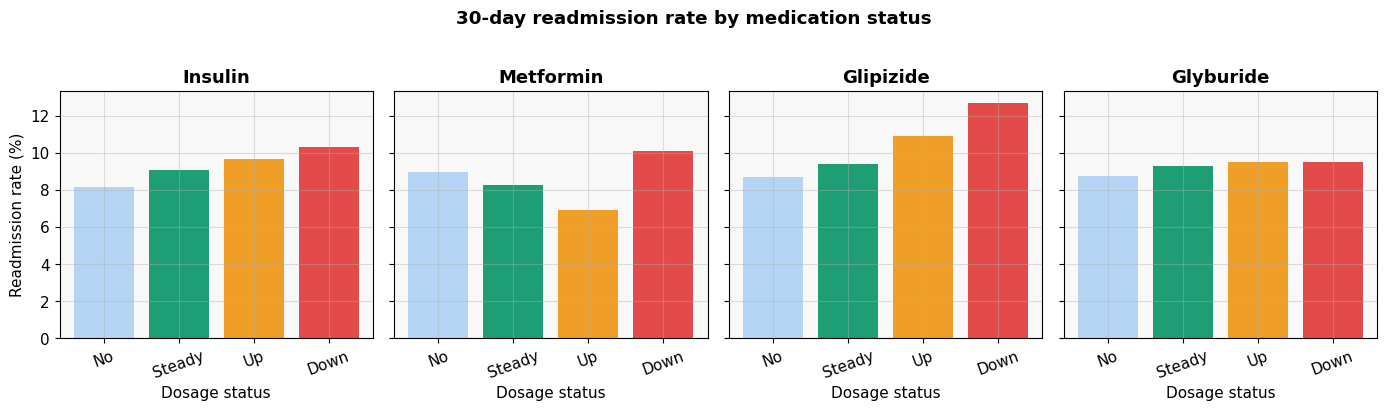

In [6]:
# Key medications and their readmission rates by status
key_meds = ['insulin', 'metformin', 'glipizide', 'glyburide']
med_status_order = ['No', 'Steady', 'Up', 'Down']

fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=True)
for ax, med in zip(axes, key_meds):
    stats = df.groupby(med)['readmitted_30'].mean().reindex(
        [s for s in med_status_order if s in df[med].unique()]
    ) * 100
    ax.bar(stats.index, stats.values,
           color=['#B5D4F4' if s == 'No' else '#1D9E75' if s == 'Steady'
                  else '#EF9F27' if s == 'Up' else '#E24B4A' for s in stats.index])
    ax.set_title(med.capitalize())
    ax.set_xlabel('Dosage status')
    if ax == axes[0]:
        ax.set_ylabel('Readmission rate (%)')
    ax.tick_params(axis='x', rotation=20)

fig.suptitle('30-day readmission rate by medication status', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/07_medication_readmission.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Utilization Features — Box Plots

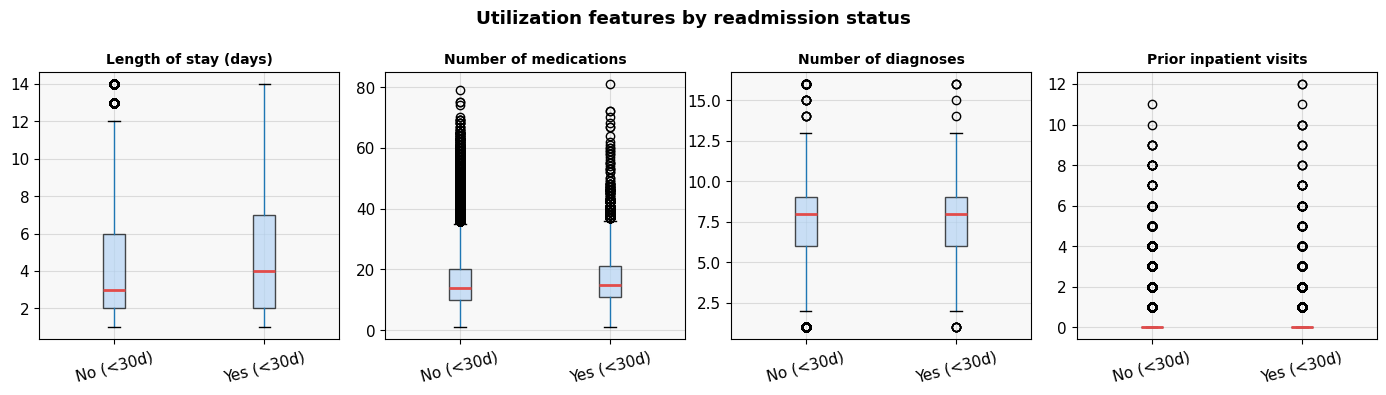

In [7]:
util_features = {
    'time_in_hospital': 'Length of stay (days)',
    'num_medications': 'Number of medications',
    'number_diagnoses': 'Number of diagnoses',
    'number_inpatient': 'Prior inpatient visits'
}

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
df['Readmission'] = df['readmitted_30'].map({0: 'No (<30d)', 1: 'Yes (<30d)'})

for ax, (col, label) in zip(axes, util_features.items()):
    df.boxplot(column=col, by='Readmission', ax=ax,
               patch_artist=True,
               boxprops=dict(facecolor='#B5D4F4', alpha=0.7),
               medianprops=dict(color='#E24B4A', linewidth=2))
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)

fig.suptitle('Utilization features by readmission status', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/08_utilization_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. HbA1c & Glucose Test Results

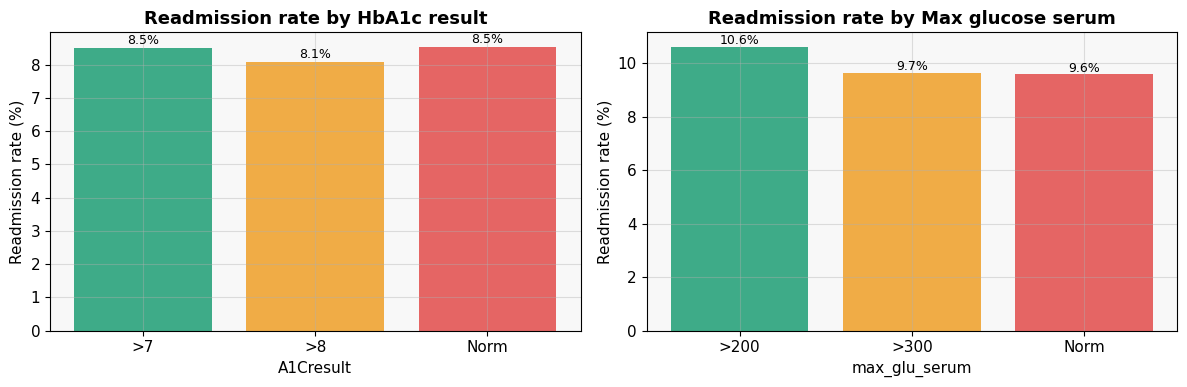

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, title in zip(
    axes,
    ['A1Cresult', 'max_glu_serum'],
    ['HbA1c result', 'Max glucose serum']
):
    stats = df.groupby(col)['readmitted_30'].agg(['mean', 'count']).reset_index()
    stats['mean'] *= 100
    stats = stats[stats['count'] > 100]
    ax.bar(stats[col].astype(str), stats['mean'],
           color=['#1D9E75', '#EF9F27', '#E24B4A', '#9B59B6'][:len(stats)], alpha=0.85)
    ax.set_title(f'Readmission rate by {title}')
    ax.set_ylabel('Readmission rate (%)')
    ax.set_xlabel(col)
    for i, (_, row) in enumerate(stats.iterrows()):
        ax.text(i, row['mean'] + 0.1, f"{row['mean']:.1f}%", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../reports/09_lab_results_readmission.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. EDA Summary

| Insight | Finding |
|---|---|
| Strongest predictor (raw) | `number_inpatient` — monotonic, large effect |
| Age effect | Readmission peaks in [70-80) age group |
| Discharge destination | Left AMA has highest readmission rate; SNF patients do better |
| Medications | Patients with insulin dose changes have slightly elevated risk |
| Lab tests | HbA1c >8 correlates with higher readmission — but most patients had no test |
| Class imbalance | ~11% positive class → will need SMOTE in modeling |

**Next**: `03_feature_engineering.ipynb`